In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

import invRrs
import glob
import os
import numpy as np
import pandas as pd
import geopandas as gpd

import xarray as xr

import matplotlib.pyplot as plt
import matplotlib as mpl

plt.rcParams.update({'font.family': 'Times New Roman',
                     'font.size': 18, 'axes.labelsize': 20,
                     })
rc = {"font.family": "serif",
      "mathtext.fontset": "stix"}
plt.rcParams.update(rc)
plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]

from invRrs import utils as u
from invRrs import solver

from aeronet_visu import data_loading as dl

opj = os.path.join

In [2]:
info = pd.read_csv('/DATA/AERONET/info_aeronet_oc_v15_location.csv',index_col=0)#.to_xarray()
info = info[info['number']>0]
xinfo = info.to_xarray()
info

,start_date,end_date,number,latitude,longitude,s2_tile
site,,,,,,
ARIAKE_TOWER,2018-02-23,2023-03-19,2001,33.103617,130.271950,52SFB
Bahia_Blanca,2020-01-23,2024-09-03,4936,-39.148000,-61.722000,20HPB
Banana_River,2022-06-16,2025-01-25,2006,28.367000,-80.633000,17RNM
Blyth_NOAH,2016-04-21,2017-09-19,33,55.146399,-1.420859,30UWG
Casablanca_Platform,2019-04-02,2025-03-31,18735,40.717000,1.358000,31TCF
Chesapeake_Bay,2021-10-07,2025-03-31,12554,39.124000,-76.359000,18SUJ
COVE_SEAPRISM,2015-11-15,2016-01-09,163,36.900000,-75.710000,18SVF
Galata_Platform,2015-02-02,2023-12-19,15072,43.044624,28.193190,35TNH
Gloria,2015-01-01,2019-08-07,7607,44.599970,29.359670,35TPK


In [3]:
site='Galata_Platform'
level='lev20'
info_ = xinfo.sel(site=site)
tile =  str(info_.s2_tile.values)
clon,clat = info_.longitude.values,info_.latitude.values
print(tile,clon,clat)
aeronet_oc = xr.open_mfdataset(opj('/DATA/AERONET/netcdf/OCv3',level,site+'*'+level+'.nc')).load().sel(time=slice('2017','2024')).sortby('wl')
aeronet_oc

35TNH 28.19319 43.044624


<xarray.Dataset>
Dimensions:                       (time: 7586, wl: 14)
Coordinates:
  * time                          (time) datetime64[ns] 2017-01-02T08:22:55 ....
  * wl                            (wl) float64 400.0 412.0 ... 870.0 1.02e+03
Data variables: (12/45)
    Aerosol_Optical_Depth         (time, wl) float64 nan 0.04732 ... nan 0.03571
    wavelength                    (time, wl) float64 nan 0.4125 ... nan 1.02
    Li_mean                       (time, wl) float64 nan 4.85 ... nan 0.1512
    Li_stddev                     (time, wl) float64 nan 0.001618 ... 0.00021
    Lt_mean                       (time, wl) float64 nan 0.4049 ... nan 0.00615
    Lt_min_rel                    (time, wl) float64 nan 0.3791 ... nan 0.004902
    ...                            ...
    year                          (time) int64 2017 2017 2017 ... 2022 2023 2023
    season                        (time) object 'DJF' 'DJF' ... 'DJF' 'DJF'
    Rrs_Lw                        (time, wl) float64 nan 0.001401 ... 9.722e-06
    Rrs_Lwn                       (time, wl) float64 nan 0.006795 ... 2.466e-05
    Rrs_Lwn_IOP                   (time, wl) float64 nan 0.005839 ... 2.466e-05
    Rrs_Lwn_fQ                    (time, wl) float64 nan 0.005964 ... 2.466e-05

In [4]:
figdir = opj('/DATA/AERONET/OCv3_invRrs/fig', site,level)
odir = opj('/DATA/AERONET/OCv3_invRrs/data', site,level)

In [5]:
# ======================
# IOP_star for algae data
# =====================
chl_models = ['Bricaud1995', 'Ciotti2002_Sf005', 'Ciotti2002_Sf01',
              'Ciotti2002_Sf02', 'Ciotti2002_Sf03', 'Ciotti2002_Sf033',
              'Ciotti2002_Sf05', 'Gernez_Mesodinium']

aphy_star, bbphy_star = u.data().load_iop_phyto(chl_models[4])

In [6]:
def earth_sun_correction(dayofyear):
    '''
    Earth-Sun distance correction factor for adjustment of mean solar irradiance

    :param dayofyear:
    :return: correction factor
    '''
    theta = 2. * np.pi * dayofyear / 365
    d2 = 1.00011 + 0.034221 * np.cos(theta) + 0.00128 * np.sin(theta) + \
         0.000719 * np.cos(2 * theta) + 0.000077 * np.sin(2 * theta)
    return d2

In [7]:
Rrs_meas[Rrs_meas<0]=0

NameError: name 'Rrs_meas' is not defined

2022-03-13T06:52:04.000000000


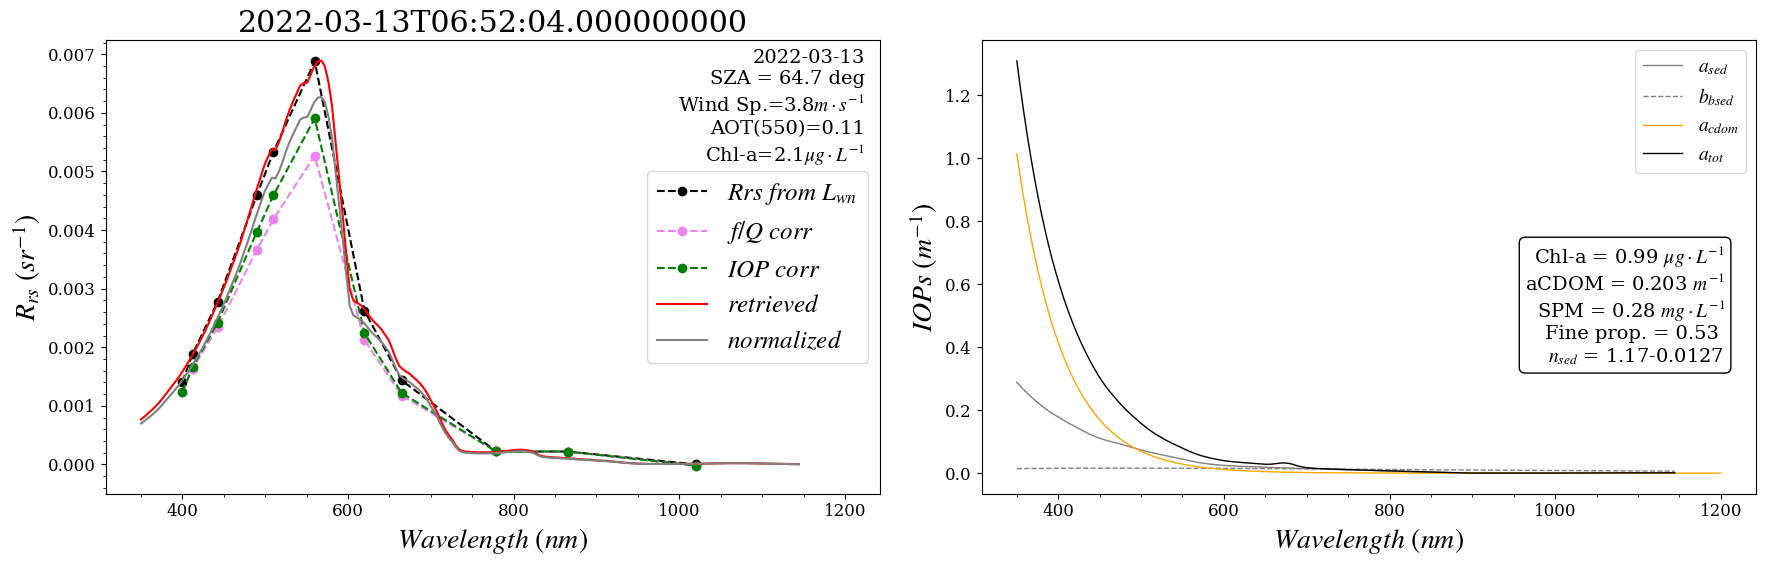

2022-03-13T06:56:43.000000000


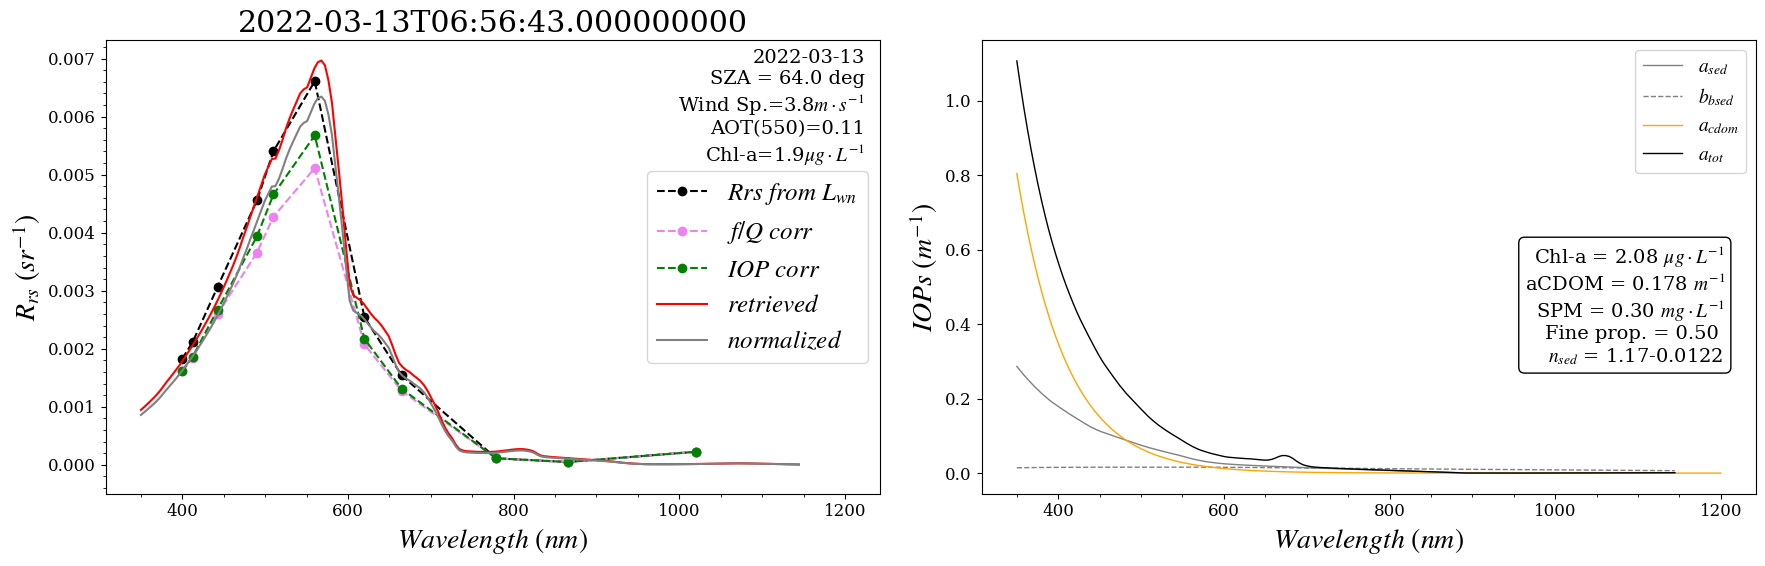

2022-03-13T07:01:22.000000000


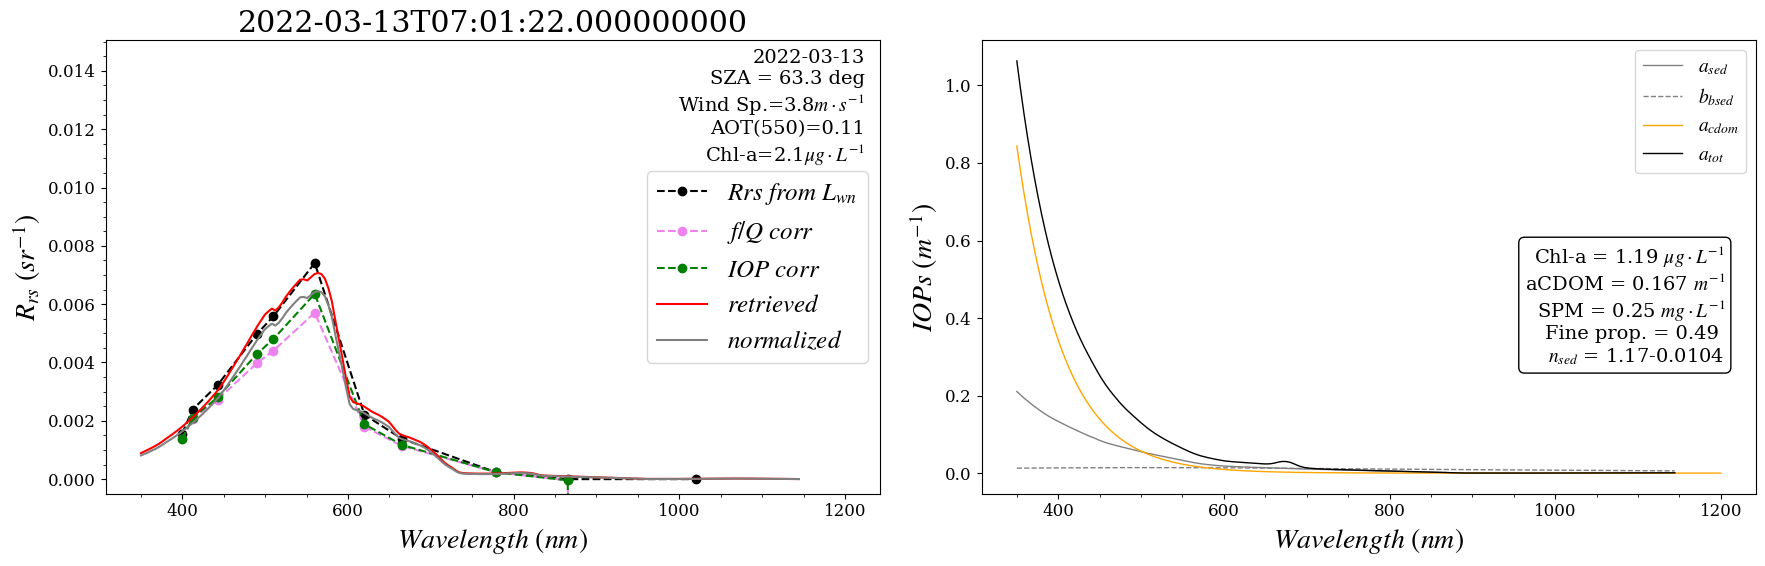

2022-03-13T07:33:46.000000000


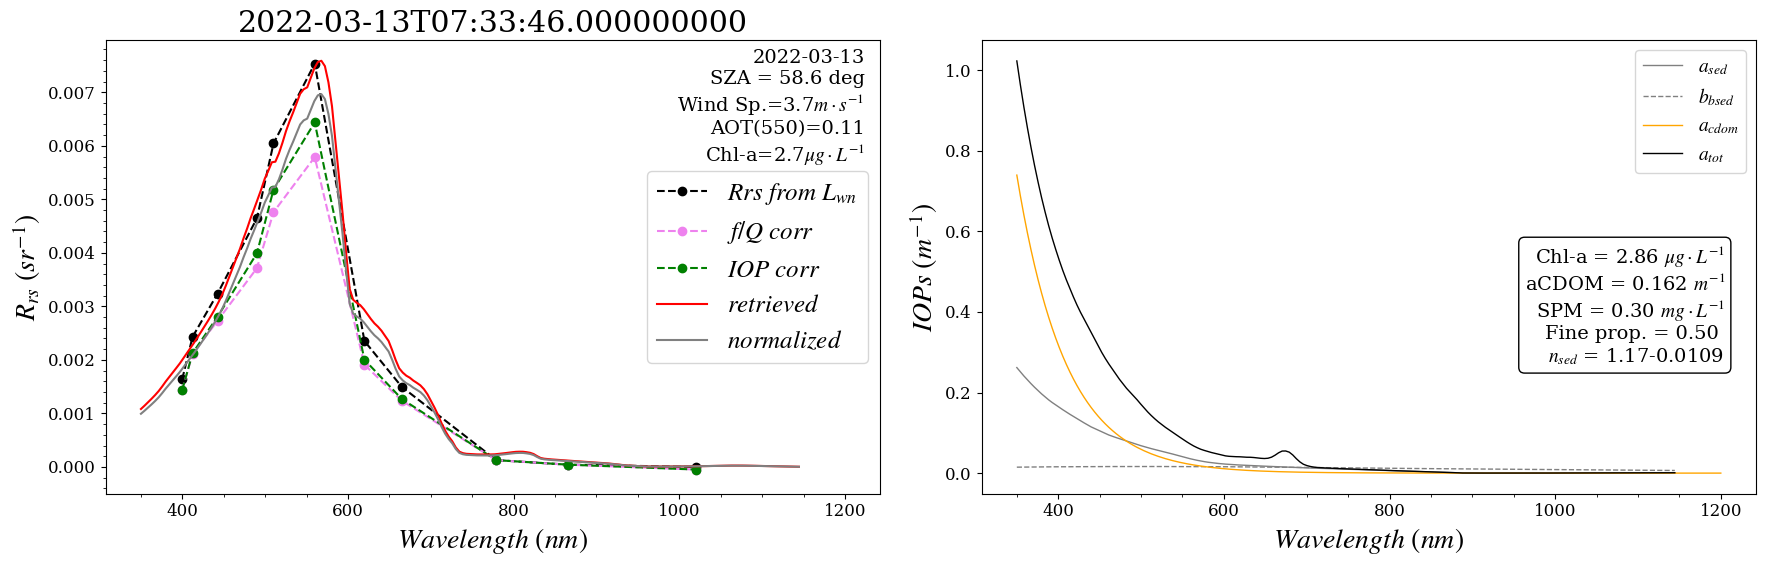

2022-03-13T07:38:25.000000000


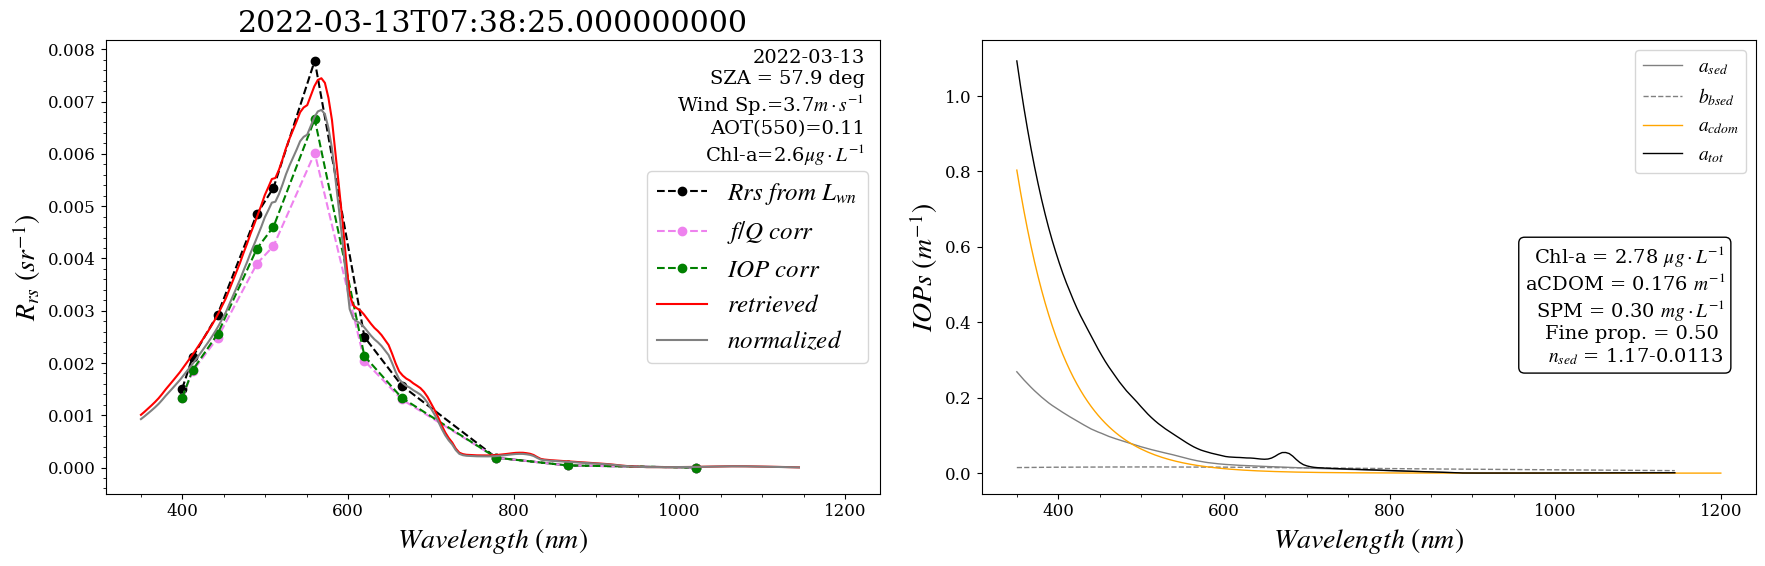

In [8]:
# ______
# ---------------------------------
# Set forward model parameters
# ---------------------------------
param = 'Rrs_Lwn'
sza = 30
density = 2.65
wl = np.linspace(350, 1100, 200)
model = solver.two_modes(aphy_star, bbphy_star, sza, wl_=wl)

# ---------------------------------
# Set forward model parameters
# ---------------------------------
i = 0
res = []
dssub = aeronet_oc.sel(time=slice('2022-03-11', '2022-12-31'))
for name, ds_ in dssub.groupby('time'):
    i += 1
    if i > 5:
        break
    print(name)
    ds_ = ds_.dropna('wl').squeeze()
    date = ds_.time.values
    #filename = opj(figdir, file.replace('.', '_') + '_' + ds_.time.dt.strftime('%Y%m%d%H%M').values + '.png')
    
    # ds_ = ds.isel(date=333)
    wl = ds_.wavelength.values * 1000
    Rrs_meas = ds_[param].values 
    # make that all values are positive
    Rrs_meas[Rrs_meas<0]=0
    # remove deep blue
    # wl=wl[1:]
    # Rrs_meas=Rrs_meas[1:]
    
    sza = ds_.SZA.values
    if sza > 80:
        continue
    
    mu0 = np.cos(np.radians(ds_.SZA))
    OT=0.52*ds_.Rayleigh_Optical_Depth+0.17*ds_.Aerosol_Optical_Depth+ds_.Ozone_Optical_Depth+ds_.Water_Vapor_Optical_Depth
    D2 = earth_sun_correction(ds_['Day_of_Year(Fraction)'])
    td = np.exp(-OT/mu0)
    Rrs_Lw = ds_.Rrs_Lw/(D2*mu0*td)
    
    aot550 = ds_.Aerosol_Optical_Depth.interp(wl=550).values
    ws = ds_['Wind_Speed(ms)'].values
    chl_a = ds_["Chlorophyll-a"].values
    vza, azi = 40, 90
    wl_simu = np.linspace(350, 1200, 200)

    chl, a_cdom, S_cdom, spm_norm, fine_prop = chl_a, 0.05, 0.017, 0.3, 0.5
    nr, ni_ref, S_ni = 1.17, -0.003, 0.005
    xinit = [chl, a_cdom, S_cdom, spm_norm, fine_prop, nr, ni_ref, S_ni]  # [0.1,2,2,0.015,0.5]

    simu = solver.two_modes(aphy_star, bbphy_star, sza, wl_=wl_simu)
    simu.set_coef(sza, vza, azi)
    Rrs_simu = simu.forward_model(xinit, output='Rrs')
    algo = solver.two_modes(aphy_star, bbphy_star, sza, wl_=wl)
    algo.set_coef(sza, vza, azi)

    # perform fit
    out = algo.call_solver(Rrs_meas, xinit=xinit, max_nfev=40)
    if out.aborted:
        x = out.last_internal_values  # continue
    else:
        x = out.x

    spm_est = density * (x[3])

    # save outcomes
    res.append([date, *x, spm_est])

    # spm_est_sd = density * np.sqrt(out.covar[3,3])
    # get parameters from forward model
    Rrs_simu, a_sed, bb_sed, a_bg, bb_tot, a_tot = simu.forward_model(x, output='all')
    simu.set_coef(sza, 0, 90)
    td = np.exp(-OT)
    Rrs_exact = simu.forward_model(x, output='Rrs')   *D2 #*  td.interp(wl=wl_simu)

    
    
    # plot results
    fig, axs = plt.subplots(1, 2, figsize=(18, 6), sharex=True)

    axs[0].plot(wl, Rrs_meas, color='black', ls='--', marker='o', label='$Rrs\ from\ L_{wn}$')
    #axs[0].plot(wl, Rrs_Lw, color='pink', ls='--', marker='o', label='$f/Q\ corr$')
    axs[0].plot(wl, ds_['Rrs_Lwn_fQ'].values, color='violet', ls='--', marker='o', label='$f/Q\ corr$')
    axs[0].plot(wl, ds_['Rrs_Lwn_IOP'].values, color='green', ls='--', marker='o', label='$IOP\ corr$')
    axs[0].plot(wl_simu, Rrs_simu, color='red', label=r'$retrieved$')
    axs[0].plot(wl_simu, Rrs_exact, color='grey', label=r'$normalized$')

    axs[0].set_ylabel(r'$R_{rs}\ (sr^{-1})$')
    axs[0].set_xlabel(r'$Wavelength\ (nm)$')
    axs[0].text(0.98, 0.98, ds_.time.dt.strftime('%Y-%m-%d').values +
                '\nSZA = {:.1f} deg'.format(sza) +
                '\nWind Sp.={:.1f}'.format(ws) + r'$m\cdot s^{-1}$' +
                '\nAOT(550)={:.2f}'.format(aot550) +
                '\nChl-a={:.1f}'.format(chl_a) + r'$\mu g\cdot L^{-1}$',
                fontsize=14,
                horizontalalignment='right',
                verticalalignment='top',
                transform=axs[0].transAxes)
    axs[0].set_title(str(date))
    axs[0].legend(loc=7)
    axs[0].set_ylim(-0.0005)
    axs[0].minorticks_on()
    axs[1].plot(wl_simu, a_sed, '-', color='grey', lw=1, label='$a_{sed}$')
    axs[1].plot(wl_simu, bb_sed, '--', color='grey', lw=1, label='$b_{bsed}$')
    axs[1].plot(wl_simu, a_bg, '-', color='orange', lw=1, label='$a_{cdom}$')
    axs[1].plot(wl_simu, a_tot, '-', color='black', lw=1, label='$a_{tot}$')
    axs[1].set_ylabel(r'$IOPs\ (m^{-1})$')
    axs[1].set_xlabel(r'$Wavelength\ (nm)$')
    axs[1].legend(fontsize=14)

    axs[1].text(0.96, 0.55,
                'Chl-a = {:.2f} '.format(x[0]) + r'$\mu g\cdot L^{-1}$' +
                '\naCDOM = {:.3f} '.format(x[1]) + r'$m^{-1}$' +
                '\nSPM = {:.2f} '.format(x[3]) + r'$mg\cdot L^{-1}$' +
                '\nFine prop. = {:.2f} '.format(x[4]) +
                '\n$n_{sed}$' + ' = {:.2f}{:.4f} '.format(x[5], x[6]),

                bbox=dict(boxstyle="round", fc='1'), fontsize=14, horizontalalignment='right',
                verticalalignment='top',
                transform=axs[1].transAxes)
    plt.tight_layout()
    plt.show()

In [9]:
   # plt.savefig(filename, dpi=300)
   # plt.close()

In [10]:
param = 'Rrs_Lwn'

# ______
# ---------------------------------
# Set forward model parameters
# ---------------------------------
sza = 30
density = 2.65
wl = np.linspace(350, 1100, 200)
model = solver.two_modes(aphy_star, bbphy_star, sza, wl_=wl)
vza, azi = 40, 90
wl_simu = np.linspace(350, 1200, 200)

# ---------------------------------
# Set forward model parameters
# ---------------------------------
i = 0

dssub = aeronet_oc.sel(time=slice('2017-01-01', '2024-12-31'))
for year, ds_ in dssub.groupby('time.year'):
    for month, ds__ in ds_.groupby('time.month'):        
        
        filename = opj(odir, site + '_' + level + '_' + f'{year}_{month:02}'+ '_v2.nc')
        if os.path.exists(filename):
            continue
        odir_ = os.path.dirname(filename)
        if not os.path.exists(odir_):
            os.makedirs(odir_)
            
        print(filename)
        res = []
        ressimu=[]
        resnadir=[]
        for time, ds___ in ds__.groupby('time'):
            i += 1
            #if i > 2:
            #    break
            
            ds___ = ds___.dropna('wl').squeeze()
            
            
            wl = ds___.wavelength.values * 1000
            Rrs_meas = ds___[param].values 
            # remove deep blue
            # wl=wl[1:]
            # Rrs_meas=Rrs_meas[1:]
        
            sza = ds___.SZA.values
            if sza > 80:
                continue
            aot550 = ds_.Aerosol_Optical_Depth.interp(wl=550).values
            ws = ds___['Wind_Speed(ms)'].values
            chl_a = ds___["Chlorophyll-a"].values
            
        
            chl, a_cdom, S_cdom, spm_norm, fine_prop = chl_a, 0.05, 0.017, 0.3, 0.5
            nr, ni_ref, S_ni = 1.17, -0.003, 0.005
            xinit = [chl, a_cdom, S_cdom, spm_norm, fine_prop, nr, ni_ref, S_ni]  # [0.1,2,2,0.015,0.5]
        
            simu = solver.two_modes(aphy_star, bbphy_star, sza, wl_=wl_simu)
            simu.set_coef(sza, vza, azi)
            Rrs_simu = simu.forward_model(xinit, output='Rrs')
            algo = solver.two_modes(aphy_star, bbphy_star, sza, wl_=wl)
            algo.set_coef(sza, vza, azi)
        
            # perform fit
            out = algo.call_solver(Rrs_meas, xinit=xinit, max_nfev=40)
            if out.aborted:
                x = out.last_internal_values  # continue
            else:
                x = out.x
        
            spm_est = density * (x[3])
        
            # save outcomes
            res.append([time, *x, spm_est])
        
            # spm_est_sd = density * np.sqrt(out.covar[3,3])
            # get parameters from forward model
            Rrs_simu, a_sed, bb_sed, a_bg, bb_tot, a_tot = simu.forward_model(x, output='all')
            simu.set_coef(sza, 0, 90)
            Rrs_nadir = simu.forward_model(x, output='Rrs')
        
            ressimu.append([time,*Rrs_simu.values])
            resnadir.append([time,*Rrs_nadir.values])
       
        
        ressimu=np.array(ressimu)
        resnadir=np.array(resnadir)
        
        hyp_aeronet_oc = xr.Dataset( data_vars=dict(Rrs=(["time","wl"],ressimu[:,1:].astype(float)),
                                                   Rrs_nadir=(["time","wl"],resnadir[:,1:].astype(float))),
            coords=dict(
                time=ressimu[:,0],
                wl= np.linspace(350, 1100, 200)),
            attrs=dict(description="InvRrs generated hyperspectral Rrs from multispectral AERONET-OC data"))
        hyp_aeronet_oc.to_netcdf(filename)

/DATA/AERONET/OCv3_invRrs/data/Galata_Platform/lev20/Galata_Platform_lev20_2017_01_v2.nc
/DATA/AERONET/OCv3_invRrs/data/Galata_Platform/lev20/Galata_Platform_lev20_2017_02_v2.nc
/DATA/AERONET/OCv3_invRrs/data/Galata_Platform/lev20/Galata_Platform_lev20_2017_03_v2.nc
/DATA/AERONET/OCv3_invRrs/data/Galata_Platform/lev20/Galata_Platform_lev20_2017_04_v2.nc
/DATA/AERONET/OCv3_invRrs/data/Galata_Platform/lev20/Galata_Platform_lev20_2017_05_v2.nc
/DATA/AERONET/OCv3_invRrs/data/Galata_Platform/lev20/Galata_Platform_lev20_2017_06_v2.nc
/DATA/AERONET/OCv3_invRrs/data/Galata_Platform/lev20/Galata_Platform_lev20_2017_07_v2.nc
/DATA/AERONET/OCv3_invRrs/data/Galata_Platform/lev20/Galata_Platform_lev20_2017_08_v2.nc
/DATA/AERONET/OCv3_invRrs/data/Galata_Platform/lev20/Galata_Platform_lev20_2017_09_v2.nc
/DATA/AERONET/OCv3_invRrs/data/Galata_Platform/lev20/Galata_Platform_lev20_2017_10_v2.nc
/DATA/AERONET/OCv3_invRrs/data/Galata_Platform/lev20/Galata_Platform_lev20_2017_11_v2.nc
/DATA/AERONET/OCv3_in

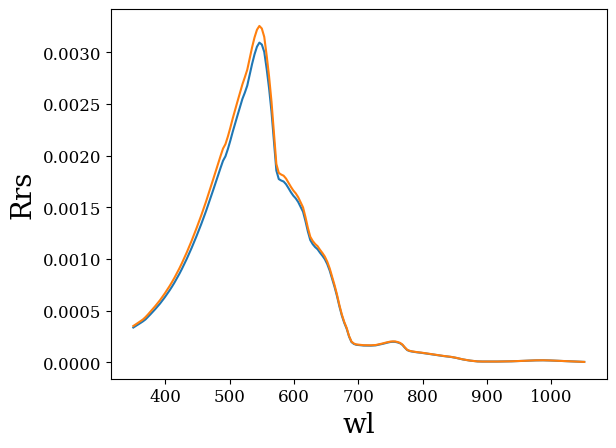

In [11]:
hyp_aeronet_oc.Rrs.plot(hue='time',add_legend=False)
plt.show()

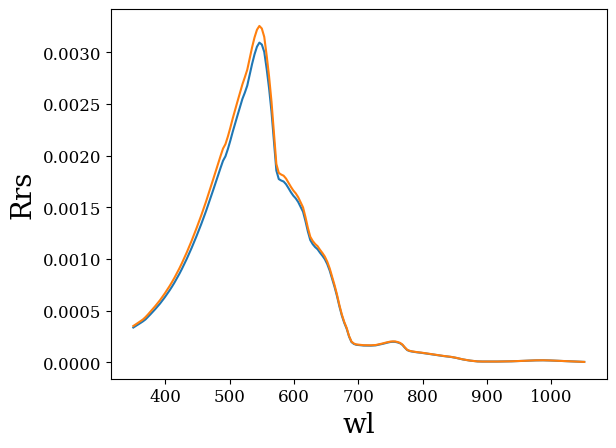

In [12]:
hyp_aeronet_oc.Rrs.plot(hue='time',add_legend=False)
plt.show()

In [41]:
ressimu=np.array(ressimu)
hyp_aeronet_oc = xr.Dataset( data_vars=dict(Rrs=(["time","wl"],ressimu[:,1:].astype(float))),
            coords=dict(
                time=ressimu[:,0],
                wl= np.linspace(350, 1100, 200)),
            attrs=dict(description="InvRrs generated hyperspectral Rrs from multispectral AERONET-OC data"))

In [39]:
hyp_aeronet_oc = xr.open_mfdataset('/DATA/AERONET/OCv3_invRrs/data/Venise_OCv3_lev/*v2.nc')
hyp_aeronet_oc

OSError: no files to open

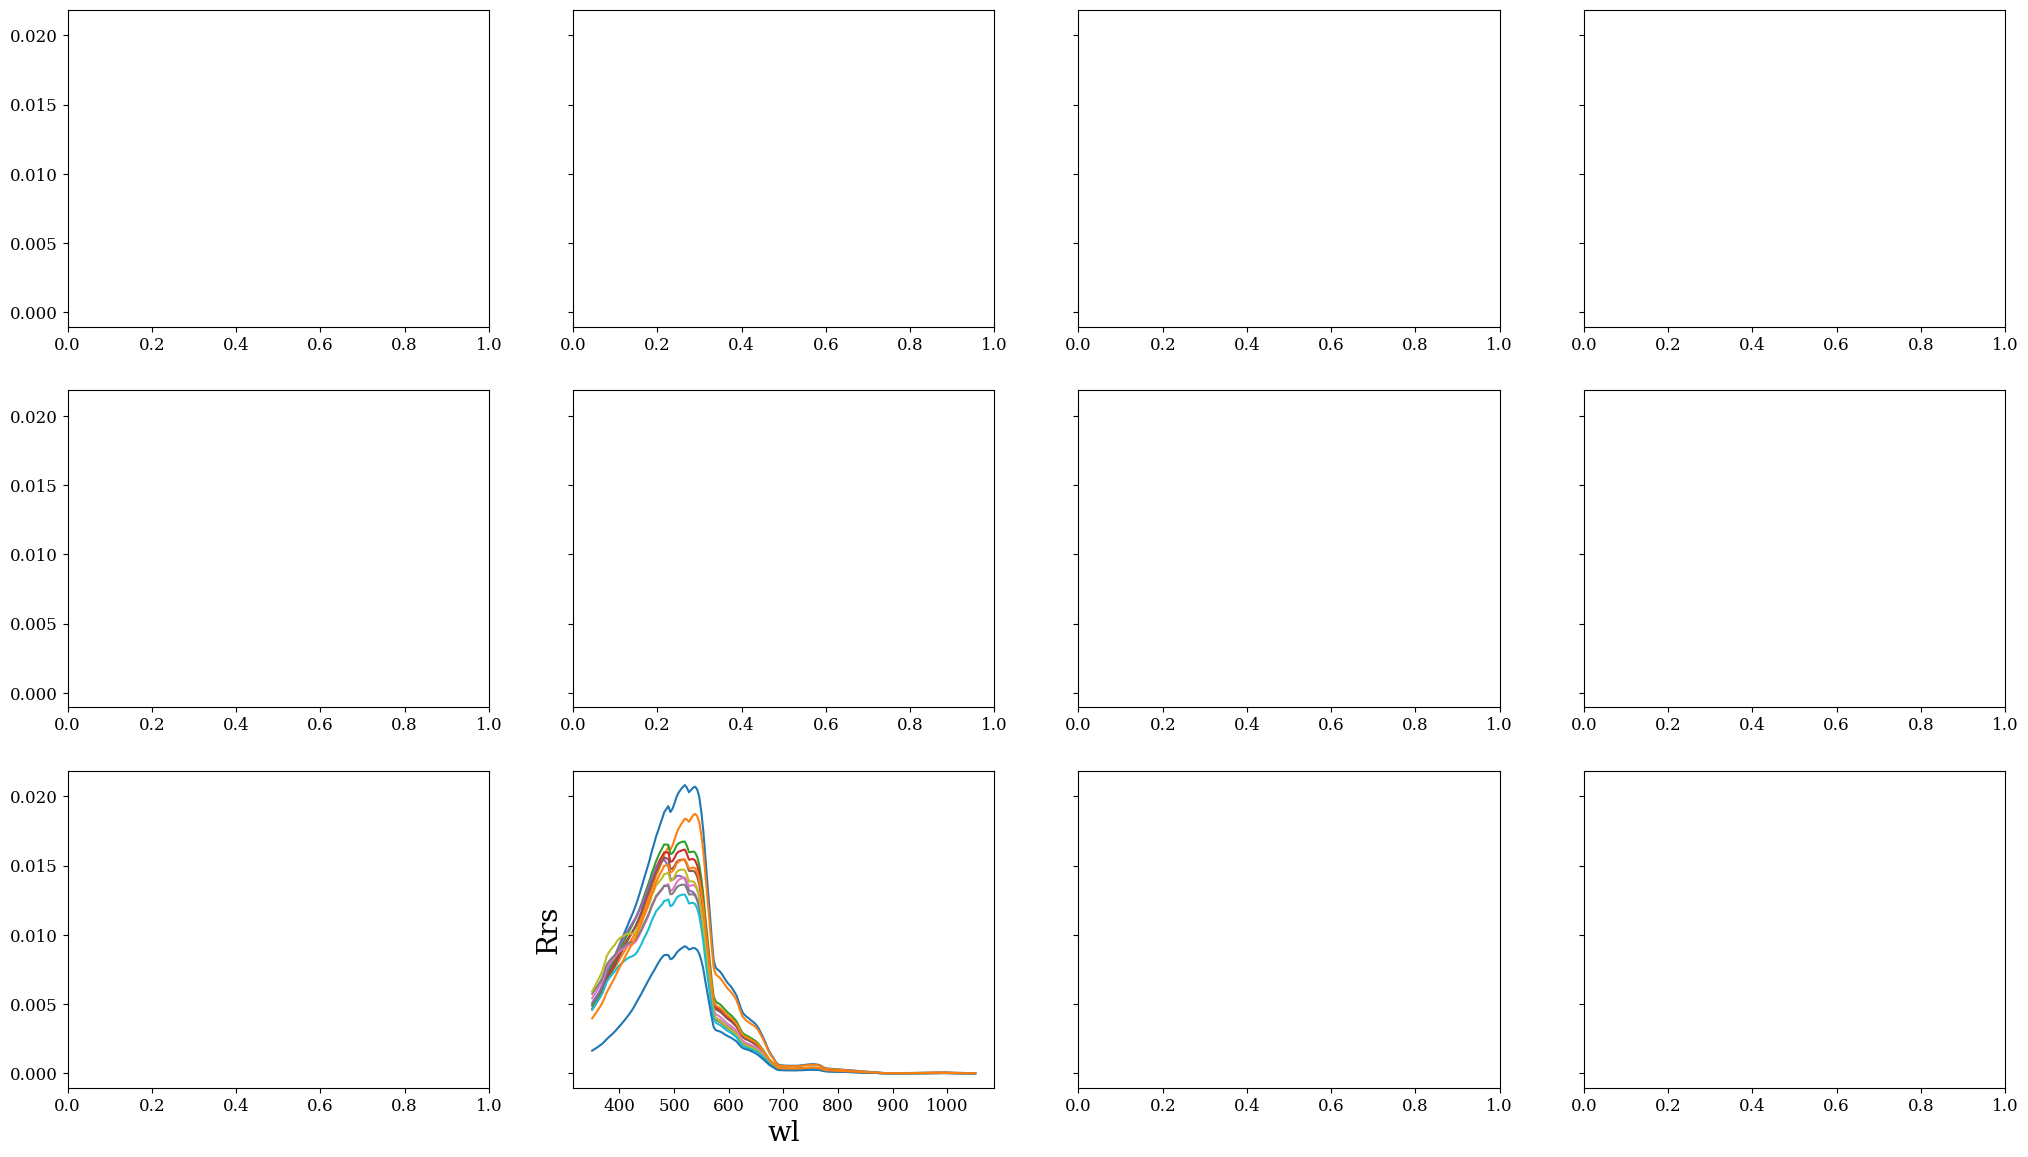

In [37]:
fig, axs = plt.subplots(3,4, figsize=(25, 14),sharey=True)
axs=axs.ravel()
for month,data in hyp_aeronet_oc.Rrs.groupby('time.month'):
    ax=axs[month-1]
    data.plot(hue='time',ax=ax,add_legend=False)
plt.show()

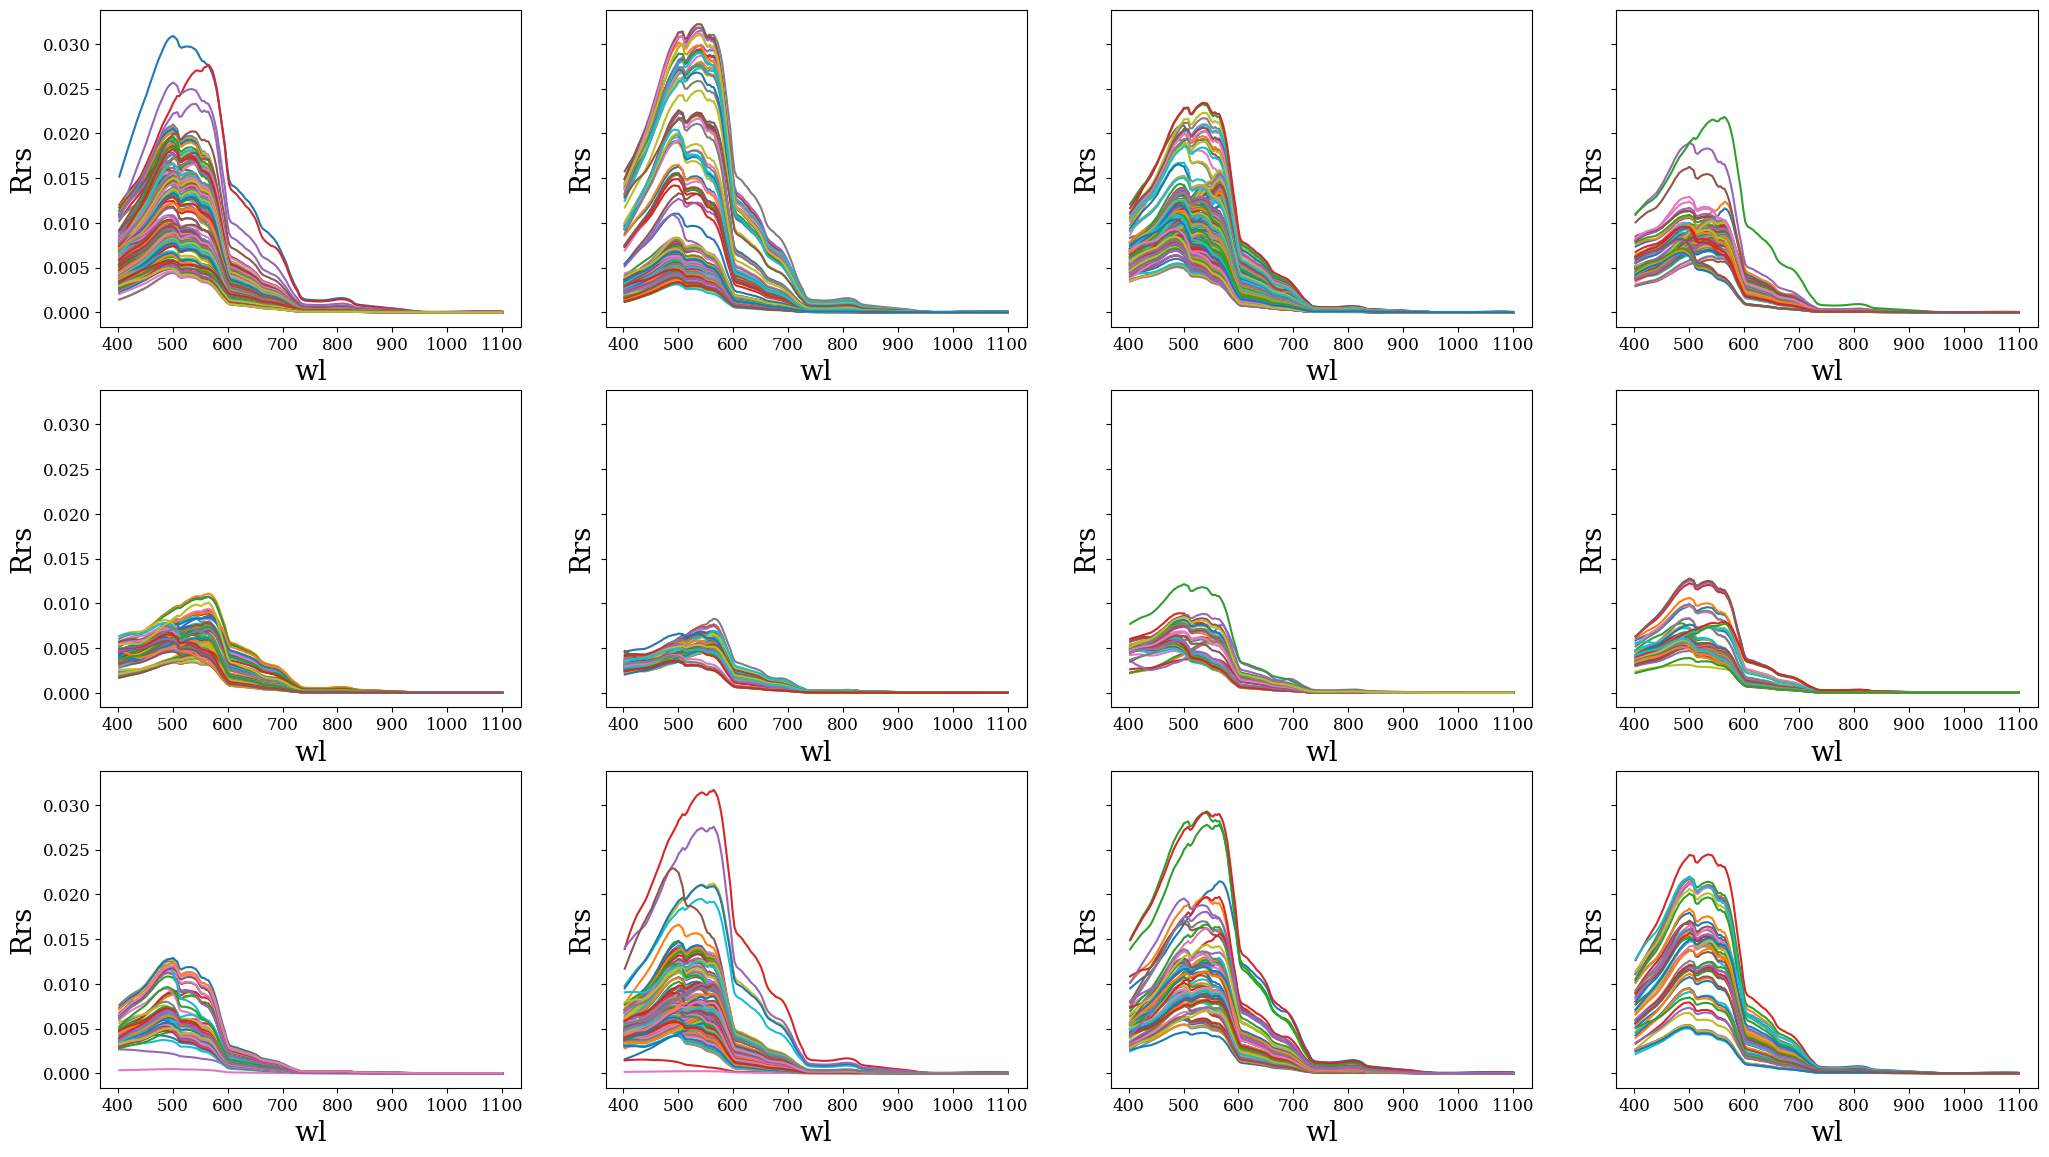

In [78]:
fig, axs = plt.subplots(3,4, figsize=(25, 14),sharey=True)
axs=axs.ravel()
for month,data in hyp_aeronet_oc.Rrs.groupby('time.month'):
    ax=axs[month-1]
    data.plot(hue='time',ax=ax,add_legend=False)
plt.show()

In [44]:
hyp_aeronet_oc.to_netcdf('/DATA/AERONET/Venise_hyp_aeronet_oc.nc')

In [61]:
f'{month:02}'

'11'

In [65]:

# ---------------------------------
# Set forward model parameters
# ---------------------------------
odir='/DATA/AERONET/OCv3_invRrs/'
i = 0
res = []
ressimu=[]
dssub = ds.sel(time=slice('2021-01-01', '2022-12-31'))
for year, ds_ in dssub.groupby('time.year'):
    for month, ds__ in ds_.groupby('time.month'):
        month = f'{month:02}'
        for time, ds___ in ds__.groupby('time'):
            i += 1
            #if i > 2:
            #    break
            #print(year,month,time)
            #ds_ = ds_.dropna('wl')
            #date = ds_.date.values
        filename = opj(odir, file.replace('.', '_') + '_' + f'{year}_{month:02}'+ '.nc')
        print(filename)

/DATA/AERONET/OCv3_invRrs/fig/Venise_OCv3_lev15/Venise_OCv3_lev15_2021_01.nc
/DATA/AERONET/OCv3_invRrs/fig/Venise_OCv3_lev15/Venise_OCv3_lev15_2021_02.nc
/DATA/AERONET/OCv3_invRrs/fig/Venise_OCv3_lev15/Venise_OCv3_lev15_2021_03.nc
/DATA/AERONET/OCv3_invRrs/fig/Venise_OCv3_lev15/Venise_OCv3_lev15_2021_04.nc
/DATA/AERONET/OCv3_invRrs/fig/Venise_OCv3_lev15/Venise_OCv3_lev15_2021_05.nc
/DATA/AERONET/OCv3_invRrs/fig/Venise_OCv3_lev15/Venise_OCv3_lev15_2021_06.nc
/DATA/AERONET/OCv3_invRrs/fig/Venise_OCv3_lev15/Venise_OCv3_lev15_2021_07.nc
/DATA/AERONET/OCv3_invRrs/fig/Venise_OCv3_lev15/Venise_OCv3_lev15_2021_08.nc
/DATA/AERONET/OCv3_invRrs/fig/Venise_OCv3_lev15/Venise_OCv3_lev15_2021_09.nc
/DATA/AERONET/OCv3_invRrs/fig/Venise_OCv3_lev15/Venise_OCv3_lev15_2021_10.nc
/DATA/AERONET/OCv3_invRrs/fig/Venise_OCv3_lev15/Venise_OCv3_lev15_2021_11.nc
/DATA/AERONET/OCv3_invRrs/fig/Venise_OCv3_lev15/Venise_OCv3_lev15_2021_12.nc
/DATA/AERONET/OCv3_invRrs/fig/Venise_OCv3_lev15/Venise_OCv3_lev15_2022_01.nc